In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Veri Kontrolü
print("Missing values:")
print(df.isnull().sum())


# 3. Zaman Serisi Görselleştirme
#plt.figure(figsize=(12, 6))
#plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
#plt.xlabel("Time")
#plt.ylabel("Value")
#plt.title("Time Series Plot of 0_x")
#plt.legend()
#plt.grid(True)
#plt.show()

Missing values:
time    0
0_x     0
dtype: int64


Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 632.0000000149012
Gerçek: 630, Tahmin: 631.0000000149012
Gerçek: 628, Tahmin: 630.0000000149012
Gerçek: 627, Tahmin: 628.0000000298023
Gerçek: 627, Tahmin: 627.0000000149012
Gerçek: 627, Tahmin: 627.0
Gerçek: 627, Tahmin: 627.0
Gerçek: 626, Tahmin: 627.0
Gerçek: 626, Tahmin: 626.0000000149012
Gerçek: 625, Tahmin: 626.0
Gerçek: 624, Tahmin: 625.0000000149012
Gerçek: 624, Tahmin: 624.0000000149012
Gerçek: 623, Tahmin: 624.0
Gerçek: 623, Tahmin: 623.0000000149012
Gerçek: 622, Tahmin: 623.0
Gerçek: 622, Tahmin: 622.0000000149012
Gerçek: 622, Tahmin: 622.0
Gerçek: 622, Tahmin: 622.0
Gerçek: 620, Tahmin: 622.0
Gerçek: 620, Tahmin: 620.0000000298023
Gerçek: 619, Tahmin: 620.0
Gerçek: 620, Tahmin: 619.0000000149012
Gerçek: 620, Tahmin: 619.9999999850988
Gerçek: 620, Tahmin: 620.0
Gerçek: 620, Tahmin: 620.0
Gerçek: 619, Tahmin: 620.0
Gerçek: 618, Tahmin: 619.0000000149012
Gerçek: 619, Tahmin: 618.0000000149013
Gerçek: 620, Tahmin: 

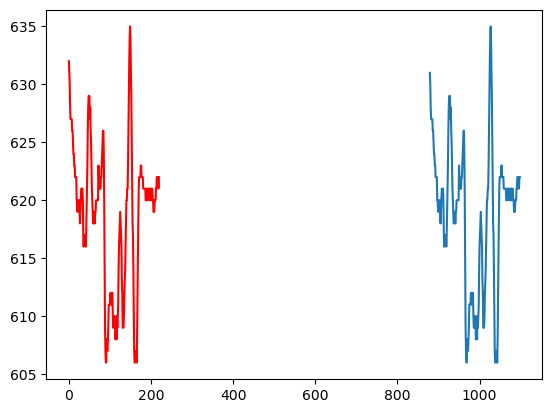

In [5]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = SimpleExpSmoothing(history) # SES modeli oluşturuluyor
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)


# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()